# What we are trying to approach?
This project performs Exploratory Data Analysis (EDA) and Feature Engineering on the Titanic dataset to prepare it for Machine Learning classification tasks.
The primary objective was to understand the dataset, identify meaningful patterns, handle missing values, engineer informative features, and transform the data into a machine-learning-ready format.

## Downloading the Data

In [2575]:
# Import the required libraries and set the display options for pandas
import pandas as pd
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2576]:
# Download the dataset and read the train and test csv files into pandas dataframes
df_train = pd.read_csv('../data/raw/train.csv')
df_test = pd.read_csv('../data/raw/test.csv')

## Understanding the Data

In [2577]:
# Verifying the structure of the dataset by checking the number of rows and columns, data types of each column, and the column names
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [2578]:
# Same for test dataset
df_test.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [2579]:
# Concatenating the train and test datasets to perform EDA on the entire dataset
df = pd.concat([df_train, df_test], ignore_index=True)
df.shape

(1309, 12)

### Important Note
Although we will aply the transformations to the test and the train dataset both but we should note that, we should not any data leakage from test to train as we only practically have the train dataset. So things like mean, median, mode and many more terms like that which deals with whole data to change the dataset, we should only use train dataset

In [2580]:
# Analyzing the data types of each column to understand the nature of the data and identify any potential issues with data types
df.dtypes

PassengerId      int64
Survived       float64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [2581]:
# Analyzing the summary statistics of the numerical columns to understand the distribution of the data and identify any potential outliers or anomalies
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


In [2582]:
# Analyzing potential patterns, information, insights and anomalies in the 'Ticket' column to understand the nature of the data and identify any potential issues with the 'Ticket' column
df['Ticket'].value_counts().sort_values(ascending=False).head(10)

Ticket
CA. 2343        11
1601             8
CA 2144          8
347082           7
347077           7
3101295          7
S.O.C. 14879     7
PC 17608         7
382652           6
19950            6
Name: count, dtype: int64

In [2583]:
# Analyzing potential patterns, information, insights and anomalies in the 'Cabin' column to understand the nature of the data and identify any potential issues with the 'Cabin' column
df['Cabin'].value_counts().sort_values(ascending=False).head(10)

/Users/shivanshpandey/Desktop/Data Science/.venv/lib/python3.14/site-packages/IPython/core/displayhook.py:292: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


Cabin
C23 C25 C27        6
B57 B59 B63 B66    5
G6                 5
F33                4
F2                 4
F4                 4
C78                4
D                  4
C22 C26            4
B96 B98            4
Name: count, dtype: int64

In [2584]:
# Analyzing potential patterns, information, insights and anomalies in the 'Pclass' column to understand the nature of the data and identify any potential issues with the 'Pclass' column
df['Pclass'].value_counts().sort_values(ascending=False).head(10)

Pclass
3    709
1    323
2    277
Name: count, dtype: int64

In [2585]:
# Analyzing potential patterns, information, insights and anomalies in the 'Embarked' column to understand the nature of the data and identify any potential issues with the 'Embarked' column
df['Embarked'].value_counts().sort_values(ascending=False).head(10)

Embarked
S    914
C    270
Q    123
Name: count, dtype: int64

In [2586]:
# Identifying the primary key
df['PassengerId'].nunique()

1309

In [2587]:
# Taking a high-level overview of the dataset by displaying the first few rows of the dataframe to understand the structure of the data and identify any potential issues with the data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Quality Assessment

In [2588]:
# Checking for duplicate rows in the dataset to identify any potential issues with duplicate data
df.duplicated().sum()

np.int64(0)

In [2589]:
# Checking for duplicate values in the 'PassengerId' column to identify any potential issues with duplicate primary key values
df['PassengerId'].duplicated().sum()

np.int64(0)

In [2590]:
# Checking for negative values in the 'Age' column to identify any potential issues with negative age values
df[df['Age'] < 0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [2591]:
# Checking for negative values in the 'Fare' column to identify any potential issues with negative fare values
df[df['Fare'] < 0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [2592]:
# Checking for missning values. Note that the Survived column has missing values in the test dataset, which is expected as it is the target variable for the test dataset
df.isna().sum().sort_values(ascending=False) / len(df) * 100

Cabin          77.463713
Survived       31.932773
Age            20.091673
Embarked        0.152788
Fare            0.076394
PassengerId     0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
dtype: float64

## Data Preparation

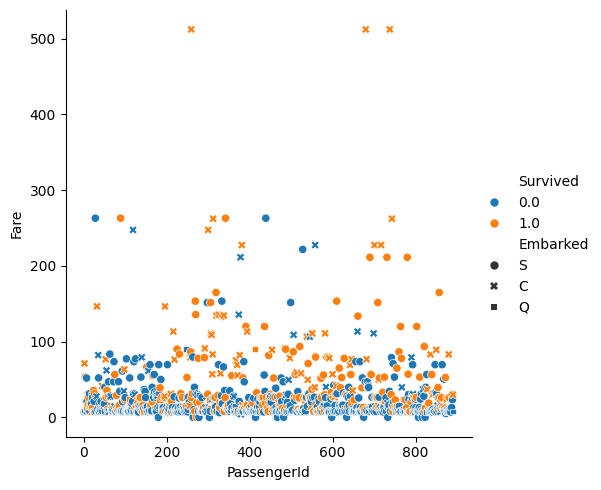

In [2593]:
# Analyzing potential patterns so as to fill the missing values
sns.relplot(data = df, x = 'PassengerId', y = 'Fare', hue = 'Survived', style = 'Embarked')

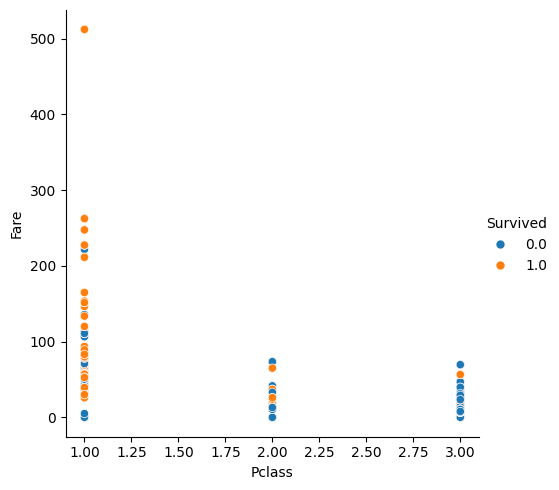

In [2594]:
# Analyzing Pclass trends with Survived and Fare to understand the relationship between these variables and identify any potential patterns or insights that can be used to fill the missing values in the 'Fare' column
sns.relplot(data = df, x = 'Pclass', y = 'Fare', hue = 'Survived')

<Axes: xlabel='Age', ylabel='Count'>

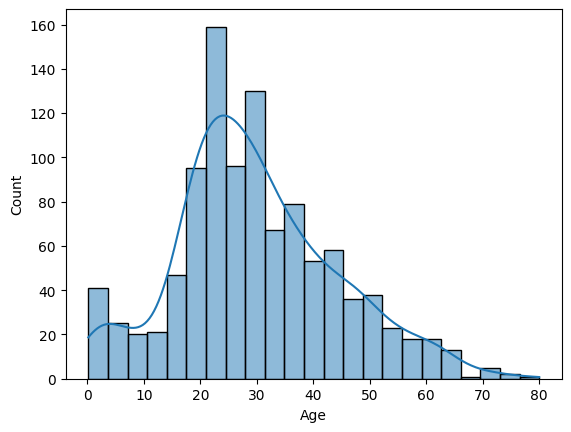

In [2595]:
# Understanding the distribution of Age Column
sns.histplot(data = df, x = 'Age',  kde = True)

In [2596]:
# Analysis to fil the age
df['Age'].describe()

count    1046.000000
mean       29.881138
std        14.413493
min         0.170000
25%        21.000000
50%        28.000000
75%        39.000000
max        80.000000
Name: Age, dtype: float64

In [2597]:
# Analysis to fil the age
df['Age'].sort_values().head(25)

1245    0.17
1092    0.33
803     0.42
755     0.67
469     0.75
644     0.75
1172    0.75
1198    0.83
78      0.83
831     0.83
305     0.92
1141    0.92
1008    1.00
788     1.00
164     1.00
172     1.00
1154    1.00
183     1.00
381     1.00
827     1.00
386     1.00
1187    1.00
824     2.00
340     2.00
119     2.00
Name: Age, dtype: float64

<Axes: xlabel='Age'>

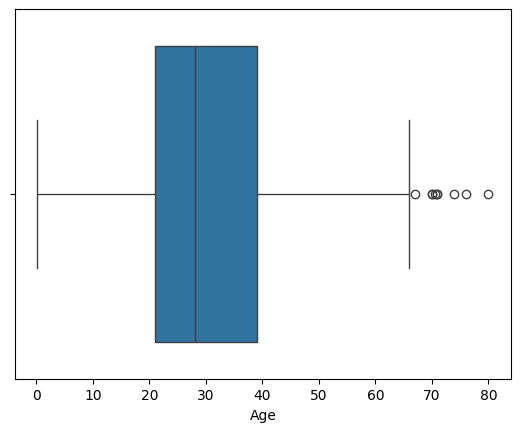

In [2598]:
# Analysis to fil the age
sns.boxplot(data = df, x = 'Age')

In [2599]:
# Analysis to fil the age
print('Median: ',df_train['Age'].median())
print('Mean: ',df_train['Age'].mean())
print('Mode: ',df_train['Age'].mode()[0])

Median:  28.0
Mean:  29.69911764705882
Mode:  24.0


<Axes: xlabel='Age'>

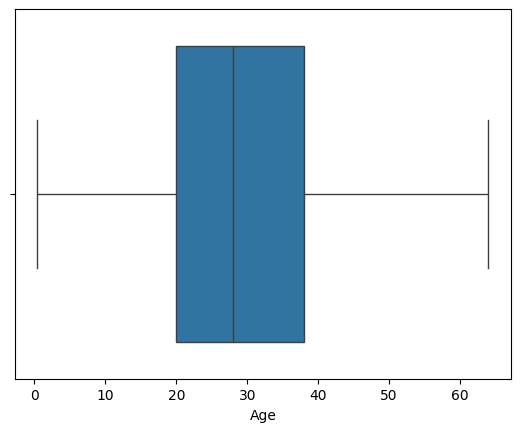

In [2600]:
# Remove Outliers by IQR method for Age 
# IQR method
# !!!IMPORTANT TO USE ONLY THE TRAINING DATASET TO PREVENT DATA LEAKAGE!!!
Q1 = df_train['Age'].quantile(0.25)
Q3 = df_train['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_no_outliers = df_train[(df_train['Age'] >= lower_bound) & (df_train['Age'] <= upper_bound)]
sns.boxplot(data = df_no_outliers, x = 'Age')

In [2601]:
# Analysis to fil the age
df_no_outliers['Age'].median()

np.float64(28.0)

In [2602]:
# Filling age finally with the median value 
df.loc[df['Age'].isna(), 'Age'] = df_no_outliers['Age'].median()

In [2603]:
# As a categorical varibale and also an important feature, we will fill the missing values in the 'Embarked' column with the mode value of the 'Embarked' column from the training dataset. This is because the mode value represents the most common value in the 'Embarked' column and is a reasonable choice for filling the missing values in this column.
print(df_train['Embarked'].value_counts())
df.loc[df['Embarked'].isna(), 'Embarked'] = df_train['Embarked'].mode()[0]

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [2604]:
# Analyzing fare to fill the missing values in the 'Fare' Column
df['Fare'].describe()

count    1308.000000
mean       33.295479
std        51.758668
min         0.000000
25%         7.895800
50%        14.454200
75%        31.275000
max       512.329200
Name: Fare, dtype: float64

<Axes: xlabel='Fare'>

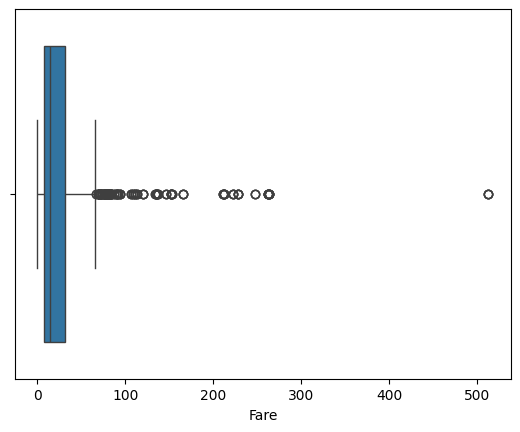

In [2605]:
# Analyzing Fare distribution to fill the missing values in the 'Fare' Column
sns.boxplot(data = df, x = 'Fare')

<Axes: xlabel='Fare'>

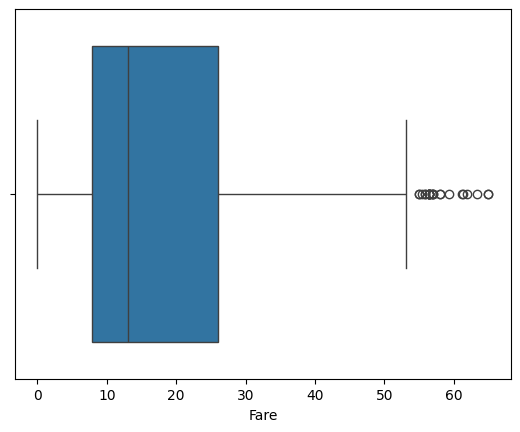

In [2606]:
# Remove Outliers by IQR method
Q1 = df_train['Fare'].quantile(0.25)
Q3 = df_train['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_no_outliers = df_train[(df_train['Fare'] >= lower_bound) & (df_train['Fare'] <= upper_bound)]
sns.boxplot(data = df_no_outliers, x = 'Fare')

In [2607]:
# Analyzing fare to fill the missing values in the 'Fare' Column
print(df_no_outliers['Fare'].median())
print(df_no_outliers['Fare'].mean())

13.0
17.82209070967742


In [2608]:
# We fill with median as it was between the two means of with and without outliers. So if number of outliers are more that doesnt creates a problem.
# Also as the distribution of fare is right skewed, median is a better measure of central tendency to fill the missing values in the 'Fare' column as it is less affected by outliers and skewed data compared to mean.
df.loc[df['Fare'].isna(), 'Fare'] = df_no_outliers['Fare'].mean()

In [2609]:
# As there are a lot of missing values we will extract the information that is present in it and later drop it.
df.loc[df['Cabin'].isna(), 'Cabin'] = 'Missing'

## Feature Engineering

In [2610]:
# We create a new column 'is_cabin_missing' to indicate whether the cabin information is missing or not. This can be useful for analysis and modeling, as the presence or absence of cabin information may have an impact on the target variable (Survived).
df['is_cabin_missing'] = df['Cabin'].apply(lambda x: 1 if x == 'Missing' else 0)

In [2611]:
# Analyzing the 'Ticket' column to extract the ticket group size and title information, which can be useful for analysis and modeling, as the ticket group size and title may have an impact on the target variable (Survived).
df['TicketGroupSize'] = df.groupby('Ticket')['Ticket'].transform('count')

# Extracting the title from the 'Name' column using regular expressions and creating a new column 'Title' to store the extracted title information. This can be useful for analysis and modeling, as the title may have an impact on the target variable (Survived).
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')

In [2612]:
# After extracting the relevant information from the 'Name' and 'Ticket' columns, we can drop these columns from the dataframe as they are no longer needed for analysis and modeling.
df.drop(columns = ['Name', 'Ticket'], inplace = True)

In [2613]:
# We create a new column 'CabinDeck' to extract the deck information from the 'Cabin' column. This can be useful for analysis and modeling, as the deck information may have an impact on the target variable (Survived).
df['CabinDeck'] = df['Cabin'].str.extract(r'([A-Za-z])\d')
df.loc[df['CabinDeck'].isna() & (df['Cabin'] != 'Missing'), 'CabinDeck'] = df['Cabin']
df.loc[df['CabinDeck'].isna(), 'CabinDeck'] = '#'

In [2614]:
# After extracting the relevant information from the 'Cabin' column, we can drop this column from the dataframe as it is no longer needed for analysis and modeling.
df = df.drop(columns = ['Cabin'])

In [2615]:
# Finally, we can perform one-hot encoding on the categorical columns 'CabinDeck', 'Title', 'Embarked', and 'Sex' as they dont have any specific order.
df = pd.get_dummies(df, columns = ['CabinDeck', 'Title', 'Embarked', 'Sex'], drop_first = False, dtype = 'int64')

In [2616]:
# Final check of consistency
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 41 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PassengerId         1309 non-null   int64  
 1   Survived            891 non-null    float64
 2   Pclass              1309 non-null   int64  
 3   Age                 1309 non-null   float64
 4   SibSp               1309 non-null   int64  
 5   Parch               1309 non-null   int64  
 6   Fare                1309 non-null   float64
 7   is_cabin_missing    1309 non-null   int64  
 8   TicketGroupSize     1309 non-null   int64  
 9   CabinDeck_#         1309 non-null   int64  
 10  CabinDeck_A         1309 non-null   int64  
 11  CabinDeck_B         1309 non-null   int64  
 12  CabinDeck_C         1309 non-null   int64  
 13  CabinDeck_D         1309 non-null   int64  
 14  CabinDeck_E         1309 non-null   int64  
 15  CabinDeck_F         1309 non-null   int64  
 16  CabinDeck_G      

In [2617]:
# Pushing survival column to the end
survived = df.pop('Survived')
df['Survived'] = survived

df.head()


,PassengerId,Pclass,Age,SibSp,Parch,Fare,is_cabin_missing,TicketGroupSize,CabinDeck_#,CabinDeck_A,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,Title_Capt,Title_Col,Title_Don,Title_Dona,Title_Dr,Title_Jonkheer,Title_Lady,Title_Major,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir,Title_the Countess,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male,Survived
0,1,3,22.0,1,0,7.2500,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0.0
1,2,1,38.0,1,0,71.2833,0,2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1.0
2,3,3,26.0,0,0,7.9250,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,1.0
3,4,1,35.0,1,0,53.1000,0,2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,1.0
4,5,3,35.0,0,0,8.0500,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0.0


## Data Exportation

In [2618]:
# After performing all the necessary data cleaning and preprocessing steps, we can now separate the processed train and test datasets based on the presence of the target variable 'Survived'. The processed train dataset will contain all the rows where 'Survived' is not null, while the processed test dataset will contain all the rows where 'Survived' is null. This separation allows us to use the processed train dataset for training our machine learning models and the processed test dataset for making predictions.
df = df.drop(columns = ['PassengerId'])
df_processed_train = df[df['Survived'].notna()]
df_processed_test = df[df['Survived'].isna()]

In [2619]:
# Finally, we can save the processed train and test datasets as separate csv files for future use in analysis and modeling.
df_processed_train.to_csv('../data/processed/processed_train.csv', index = False)

In [2620]:
# For the test dataset, we drop the 'Survived' column as it contains only null values and is not needed for analysis and modeling. We then save the processed test dataset as a separate csv file for future use in making predictions with our machine learning models.
df_processed_test.drop(columns = ['Survived'], inplace = True)
df_processed_test.to_csv('../data/processed/processed_test.csv', index = False)